In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def ratios(filename):
    """
    Given the csv with the trajectories of the simulations 
    this function calculates the percentaje, for each time, of trajectories
    with x0+x2+x3 >= 2
    """
    df = pd.read_csv(filename)
    
    dftmax = df.groupby('Trajectory').max().reset_index()
    df = pd.merge(df, dftmax[['Trajectory','Time']], on='Trajectory', suffixes=('','max'))
    df = df[df['Timemax'] >= 500]
    print(df.shape)

    df['x0x2x3'] = df['x0']+df['x2']+df['x3']
    Totales = len(df['Trajectory'].unique())
    df['x0x2x3>=2'] = df['x0x2x3'] >= 2
    dfg = df.groupby('Time').sum().reset_index()
    dfg['x0x2x3>=2'] /= Totales

    strings = filename.split('_')
    dfg['IC'] = strings[3] #initial contidion
    dfg['kCS'] = strings[-1][:-4] #Collateral sensitivity parameter
    
    return dfg[['Time','x0x2x3>=2','IC','kCS']]

In [5]:
lcsv = [
    'traj_plot_ratiox3_x290_cs005.csv',
    'traj_plot_ratiox3_x050_cs005.csv',
]

df = pd.DataFrame()

for filename in lcsv:
    data = ratios(filename)
    df = pd.concat([df,data])

df

(50000000, 8)
(50000000, 8)


,Time,x0x2x3>=2,IC,kCS
0,0.1,1.0000,x290,cs005
1,0.2,1.0000,x290,cs005
2,0.3,1.0000,x290,cs005
3,0.4,1.0000,x290,cs005
4,0.5,1.0000,x290,cs005
...,...,...,...,...
4995,499.6,0.6162,x050,cs005
4996,499.7,0.6185,x050,cs005
4997,499.8,0.6149,x050,cs005
4998,499.9,0.6176,x050,cs005


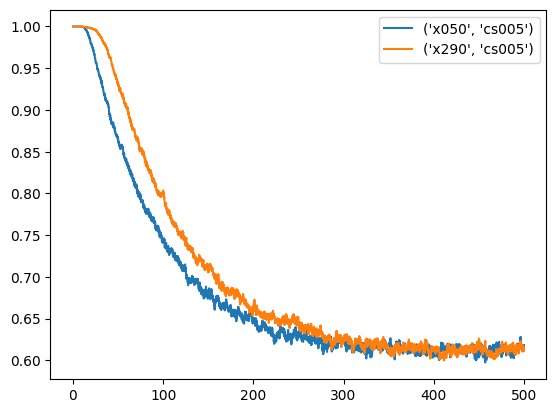

In [6]:
for u, dfu in df.groupby(['IC','kCS']):
    plt.plot(dfu['Time'], dfu['x0x2x3>=2'],label=str(u))
plt.legend()
plt.show()

In [12]:
df.to_csv('ratios.csv')